In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
data = pd.read_csv("car_acceptability.csv")
df = pd.DataFrame(data)

In [3]:
le = LabelEncoder()

df["buying price"] = le.fit_transform(df["buying price"])
df["maintenance cost"] = le.fit_transform(df["maintenance cost"])
df["lug_boot"] = le.fit_transform(df["lug_boot"])
df["safety"] = le.fit_transform(df["safety"])
df["evaluation"] = le.fit_transform(df["evaluation"])

In [4]:
X = df.drop("evaluation", axis =1)
Y = df["evaluation"]

In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

In [6]:
svm_model = SVC(kernel = 'linear')
svm_model.fit(X_train, Y_train)

SVC(kernel='linear')

In [7]:
Y_pred = svm_model.predict(X_test)

In [8]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))
cm = confusion_matrix(Y_test, Y_pred)
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.7138728323699421

Confusion Matrix:
 [[ 12   0  65   0]
 [  0   0  15   0]
 [  2   0 235   0]
 [ 12   0   5   0]]


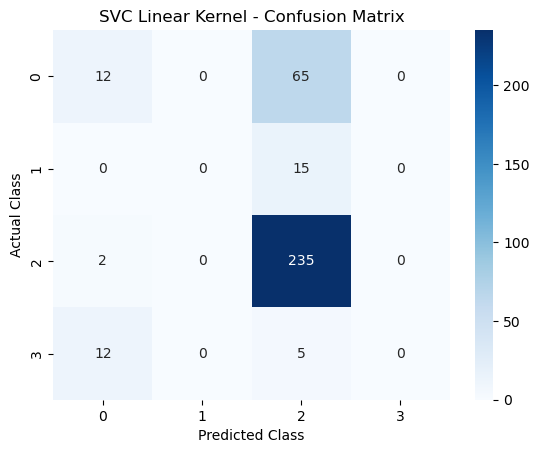

In [9]:
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("SVC Linear Kernel - Confusion Matrix")
plt.show()

In [10]:
svm_model = SVC(kernel = 'poly')
svm_model.fit(X_train, Y_train)

SVC(kernel='poly')

In [11]:
Y_pred = svm_model.predict(X_test)

In [12]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))
cm = confusion_matrix(Y_test, Y_pred)
print("\nConfusion Matrix:\n", cm)

Accuracy: 0.838150289017341

Confusion Matrix:
 [[ 50   0  26   1]
 [  6   4   2   3]
 [ 13   0 224   0]
 [  4   0   1  12]]


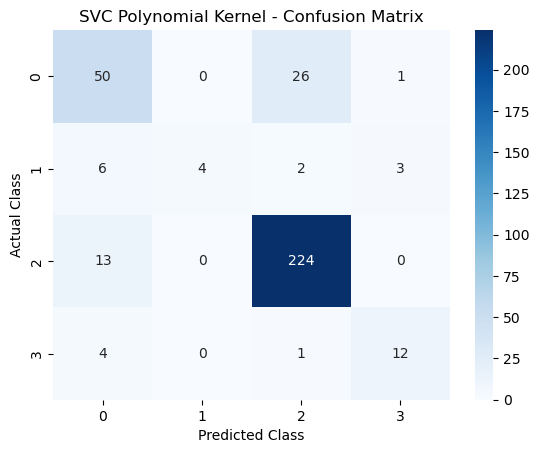

In [13]:
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("SVC Polynomial Kernel - Confusion Matrix")
plt.show()